In [39]:
import config 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import networkx as nx
import random 
random.seed(67)

In [3]:
df_features = pd.read_csv(config.FEATS_PATH, header=None)
df_labels = pd.read_csv(config.LABELS_PATH)

In [9]:
df_joined = df_features.merge(df_labels, left_on=0, right_on="txId", how="inner")
df_joined.drop(["txId"], axis=1, inplace=True)

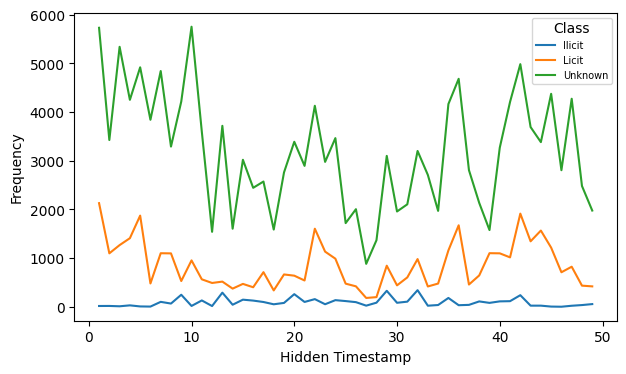

In [ ]:
# There are some peaks in some timestamps, might be a key indicator later.
# Looks like Unknown has a similar distribution to Licit + Illicit
df_joined.groupby(1).agg({"class":"value_counts"}).unstack().plot(figsize=(7, 4))
plt.xlabel("Hidden Timestamp")
plt.ylabel("Frequency")
plt.legend(title="Class", labels=["Ilicit", "Licit", "Unknown"], 
           fontsize=7)
plt.show()

In [44]:
# Most of the data is unknown so I'm only plotting class 1 and 2
df_labeled = df_joined.loc[df_joined.loc[:, "class"].isin(["1", "2"])]
feats_to_plot = random.sample([x for x in range(1, 166)], 4)


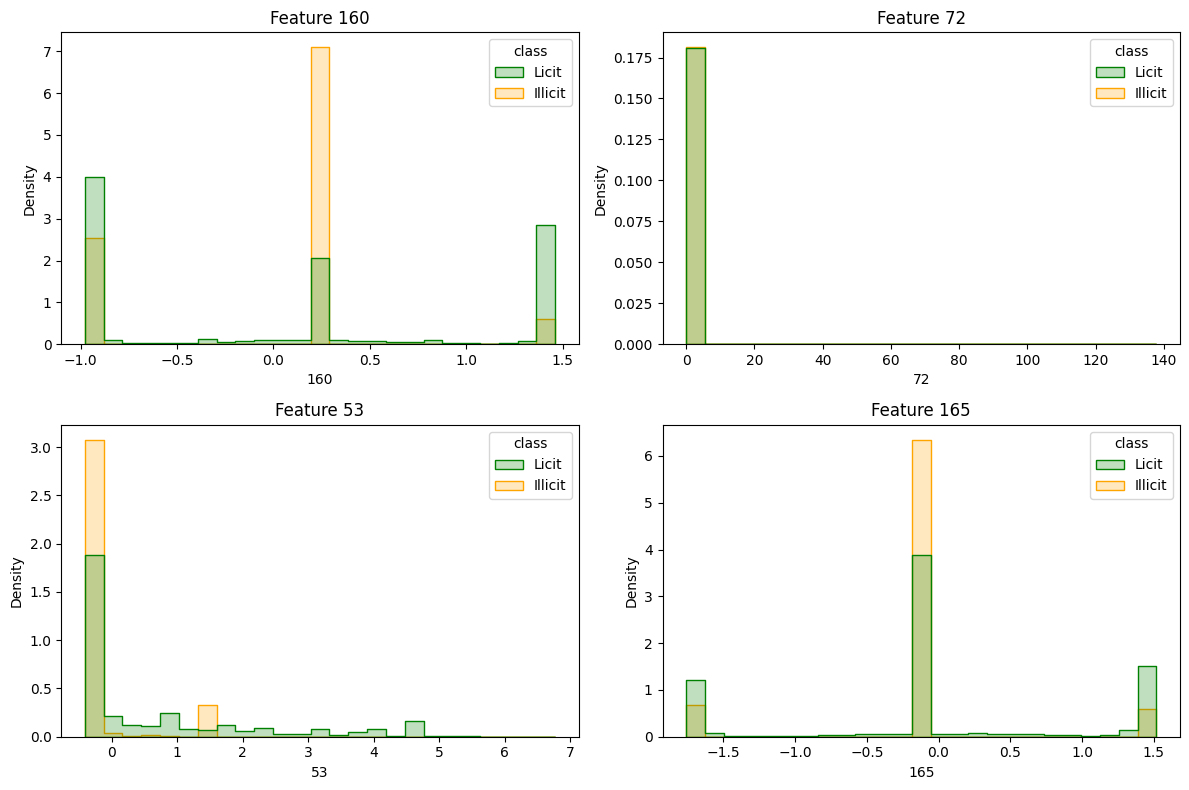

In [ ]:
# Some of these features seem to have potential
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(feats_to_plot):
    ax = axes[i // 2, i % 2]
    sns.histplot(
        data = df_labeled,
        x=col,
        hue=df_labeled["class"].map({"1":"Illicit", "2":"Licit"}),
        bins=25,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
        palette = {"Illicit": "orange", "Licit": "green"}
    )
    ax.set_title(f"Feature {col}")
plt.tight_layout()
plt.show()
    

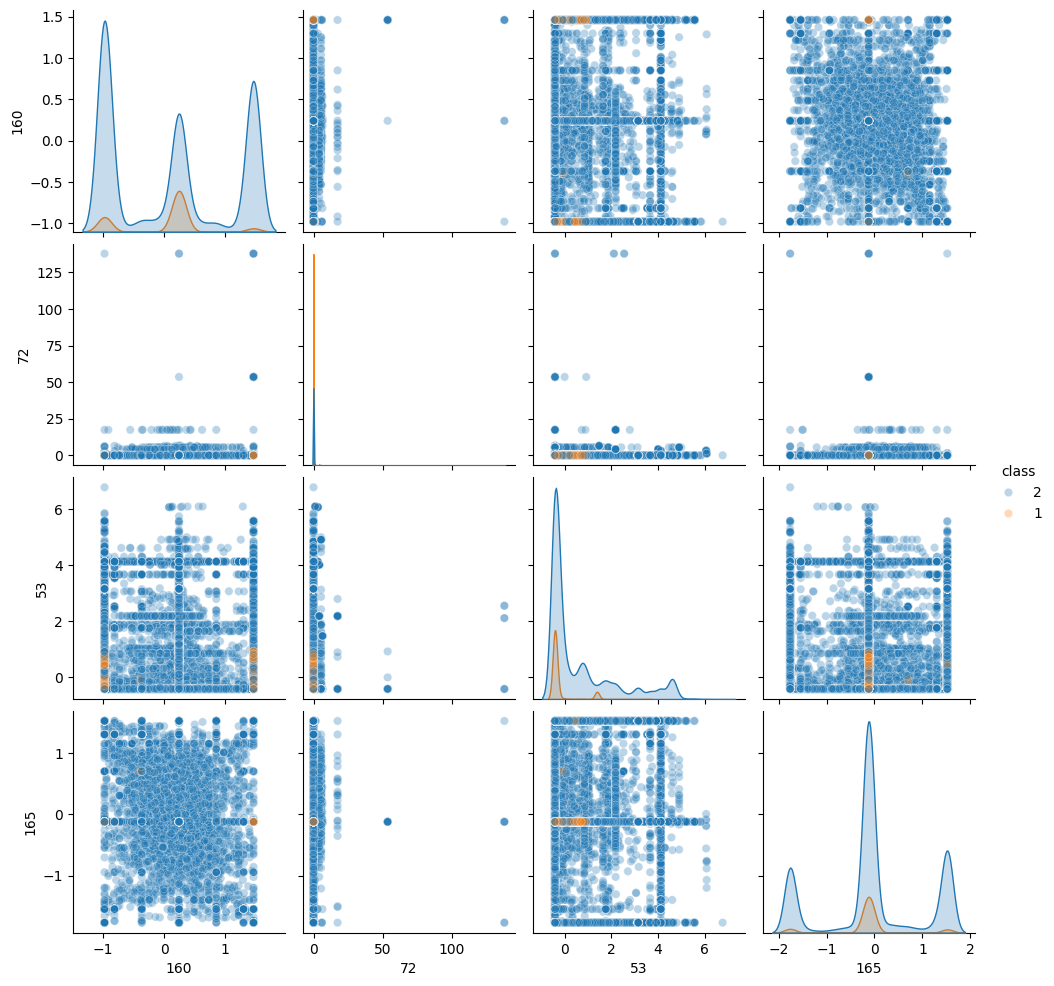

<Figure size 200x200 with 0 Axes>

In [ ]:
# Don't see any strong correlation on these features
sns.pairplot(
    df_labeled[feats_to_plot + ["class"]],
    hue="class",
    plot_kws={"alpha": 0.3}
)
plt.show()

In [60]:
G = nx.from_pandas_edgelist(
    pd.read_csv(config.EDGES_PATH),
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph
)

In [ ]:
# Not a crazy amount of edges
G.number_of_nodes(), G.number_of_edges()

(203769, 234355)

In [70]:
# Add labels to data 
nx.set_node_attributes(G, dict(zip(df_labels.loc[:, "txId"], df_labels.loc[:, "class"])), "label")

In [ ]:
# Get connected components
components = list(nx.weakly_connected_components(G))
len(components)
# Not that many

49

In [ ]:
# Largest component is suspiciously big
largest = max(components, key=len)
len(largest)

7880

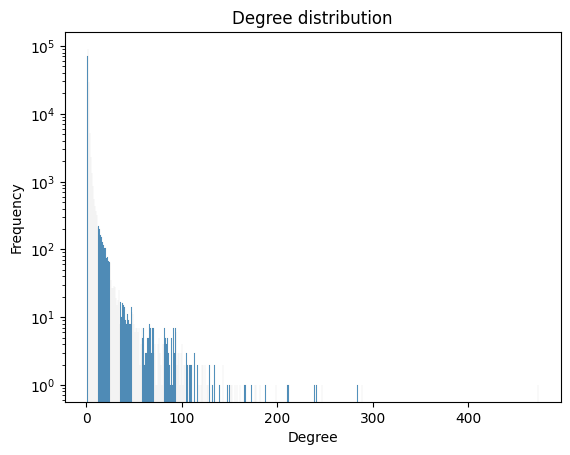

In [80]:
sns.histplot([d for _, d in G.degree()])
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
# It was looking weird without this
plt.yscale("log")
plt.show()
# There are some highly connected nodes

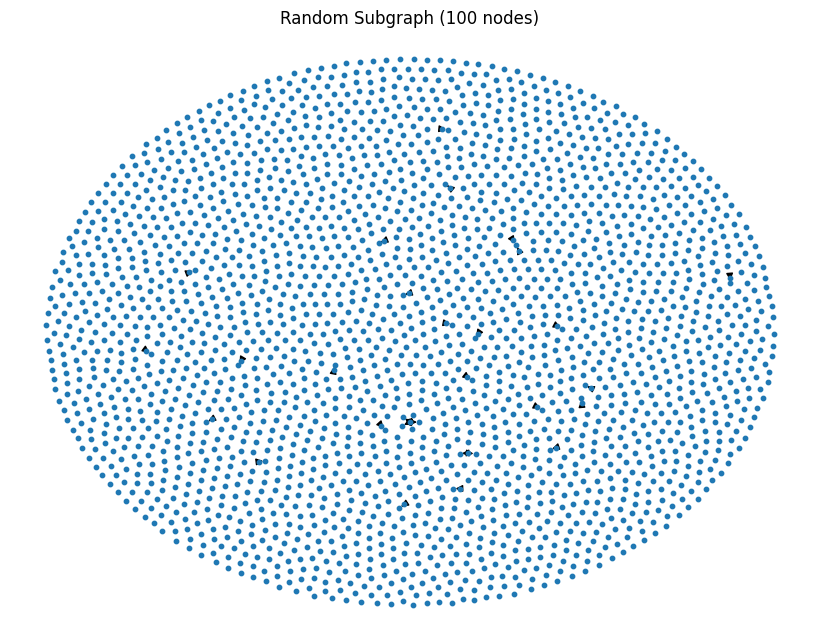

In [ ]:
# Plot a random sample
sub_nodes = random.sample(list(G.nodes()), 2500)
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(8, 6))
nx.draw(subgraph, node_size=10)
plt.title("Random subgraph 2500 nodes")
plt.show()
# Seems like most of the nodes are isolated in this sample, can't see a shape on this.